<a href="https://colab.research.google.com/github/mariea-aashif/Statistical-Learning-e22374/blob/main/assignment_8_maximum_entropy_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Mechanics of the Quantum Oscillator

Consider a quantum harmonic oscillator with energy eigenvalues

$$
E_j=\hbar\omega\left(j+\frac12\right),
\qquad
j=0,1,2,\ldots
$$

The probability of the oscillator occupying the energy state \(E_j\) is determined by maximizing the entropy

$$
H=-\sum_j p_j\ln p_j
$$

subject to the constraints

$$
\sum_j p_j=1,
$$

and

$$
\sum_j p_jE_j=\bar E,
$$

where \(\bar E\) is the average energy.

## Maximum Entropy Distribution

The constrained optimization problem is solved using Lagrange multipliers.

Define the Lagrangian

$$
\mathcal L
=
-\sum_j p_j\ln p_j
+\lambda\left(\sum_j p_j-1\right)
+\beta\left(\sum_j p_jE_j-\bar E\right).
$$

Taking the derivative with respect to \(p_j\),

$$
\frac{\partial\mathcal L}{\partial p_j}
=
-\ln p_j-1+\lambda+\beta E_j.
$$

Setting the derivative equal to zero,

$$
-\ln p_j-1+\lambda+\beta E_j=0.
$$

Therefore,

$$
p_j
=
\exp(\lambda-1)\exp(-\beta E_j).
$$

Using the normalization condition,

$$
\sum_j p_j=1,
$$

gives

$$
\exp(\lambda-1)=\frac1Z,
$$

where

$$
Z=\sum_{j=0}^{\infty}\exp(-\beta E_j)
$$

is called the partition function.

Hence, the maximum entropy distribution is

$$
p_j
=
\frac{\exp(-\beta E_j)}{Z}.
$$

## Partition Function

Substituting

$$
E_j=\hbar\omega\left(j+\frac12\right),
$$

the partition function becomes

$$
Z
=
\sum_{j=0}^{\infty}
\exp\left[
-\beta\hbar\omega\left(j+\frac12\right)
\right].
$$

Separating the constant term,

$$
Z
=
e^{-\beta\hbar\omega/2}
\sum_{j=0}^{\infty}
\left(e^{-\beta\hbar\omega}\right)^j.
$$

Since this is a geometric series,

$$
\sum_{j=0}^{\infty}r^j
=
\frac1{1-r},
\qquad |r|<1,
$$

we obtain

$$
Z
=
\frac{
e^{-\beta\hbar\omega/2}
}
{
1-e^{-\beta\hbar\omega}
}.
$$

## Mean Energy

The average energy is obtained from the partition function using

$$
\bar E
=
-\frac{\partial}{\partial\beta}
\ln Z.
$$

Since

$$
\ln Z
=
-\frac{\beta\hbar\omega}{2}
-
\ln\left(1-e^{-\beta\hbar\omega}\right),
$$

differentiating gives

$$
\bar E
=
\frac{\hbar\omega}{2}
+
\frac{\hbar\omega}
{e^{\beta\hbar\omega}-1}.
$$

The first term represents the zero-point energy of the oscillator, while the second term corresponds to the thermal energy contribution.

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (normalized units)
hbar = 1.0
omega = 1.0
beta = 1.0

# Energy levels
j = np.arange(0, 15)

E = hbar * omega * (j + 0.5)

# Partition function
Z = np.sum(np.exp(-beta * E))

# Boltzmann probabilities
P = np.exp(-beta * E) / Z

print("Partition Function =", Z)
print("Probabilities:\n", P)

Partition Function = 0.9595170821488799
Probabilities:
 [6.32120752e-01 2.32544229e-01 8.55482410e-02 3.14714391e-02
 1.15776954e-02 4.25919613e-03 1.56687069e-03 5.76419514e-04
 2.12052889e-04 7.80098982e-05 2.86982378e-05 1.05574917e-05
 3.88388413e-06 1.42880112e-06 5.25626559e-07]


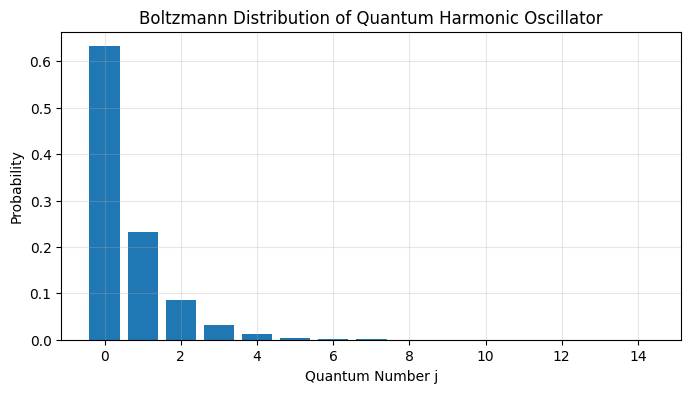

In [67]:
plt.figure(figsize=(8,4))

plt.bar(j, P)

plt.xlabel("Quantum Number j")
plt.ylabel("Probability")
plt.title("Boltzmann Distribution of Quantum Harmonic Oscillator")

plt.grid(True, alpha=0.3)
plt.show()

## Discussion

The probability decreases exponentially as the energy level increases. Consequently, the oscillator is most likely to occupy lower energy states, while higher energy states have progressively smaller probabilities. This behaviour follows the Boltzmann distribution and is consistent with the principles of statistical mechanics.

# Maximum Entropy Distribution under Mean and Variance Constraints

Let \(X\) be a continuous random variable with probability density function \(p(x)\). The entropy is defined as

$$
H = -\int_{-\infty}^{\infty} p(x)\ln p(x)\,dx.
$$

The probability density function must satisfy the following constraints:

$$
\int_{-\infty}^{\infty} p(x)\,dx = 1,
$$

$$
\int_{-\infty}^{\infty} xp(x)\,dx = \mu,
$$

and

$$
\int_{-\infty}^{\infty}(x-\mu)^2p(x)\,dx=\sigma^2.
$$

The objective is to determine the probability density function that maximizes the entropy while satisfying these constraints.

## Derivation of the Maximum Entropy Distribution

The constrained optimization problem is solved using the method of Lagrange multipliers.

The functional is

$$
\mathcal{L}
=
-\int p(x)\ln p(x)\,dx
+\lambda_0\left(\int p(x)\,dx-1\right)
+\lambda_1\left(\int xp(x)\,dx-\mu\right)
+\lambda_2\left(\int (x-\mu)^2p(x)\,dx-\sigma^2\right).
$$

Taking the functional derivative with respect to \(p(x)\),

$$
\frac{\partial\mathcal L}{\partial p(x)}
=
-\ln p(x)-1+\lambda_0+\lambda_1x+\lambda_2(x-\mu)^2.
$$

Setting the derivative equal to zero gives

$$
\ln p(x)
=
\lambda_0-1+\lambda_1x+\lambda_2(x-\mu)^2.
$$

Therefore,

$$
p(x)
=
A
\exp\!\left(
\lambda_1x+\lambda_2(x-\mu)^2
\right),
$$

where

$$
A=e^{\lambda_0-1}.
$$

Since the density must integrate to one over the real line, the quadratic coefficient must be negative. Applying the normalization, mean, and variance constraints gives

$$
\lambda_1=0,
$$

and

$$
\lambda_2=-\frac{1}{2\sigma^2}.
$$

Hence,

$$
p(x)
=
A
\exp\!\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right).
$$

Using the normalization condition,

$$
A=\frac1{\sqrt{2\pi\sigma^2}}.
$$

Therefore, the maximum entropy distribution is

$$
p(x)
=
\frac1{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right),
$$

which is the Gaussian (Normal) distribution.

## Discussion

Among all continuous probability distributions having the same mean and variance, the Gaussian distribution possesses the largest entropy. This means it is the least biased distribution because it introduces no additional assumptions beyond the specified constraints. Consequently, the Normal distribution naturally arises as the maximum entropy solution when only the first and second moments are known.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
# Parameters
mu = 0
sigma = 1

# Generate x values
x = np.linspace(-5, 5, 500)

# Gaussian probability density function
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(
    -((x - mu) ** 2) / (2 * sigma ** 2)
)

print(f"Mean = {mu}")
print(f"Standard Deviation = {sigma}")

Mean = 0
Standard Deviation = 1


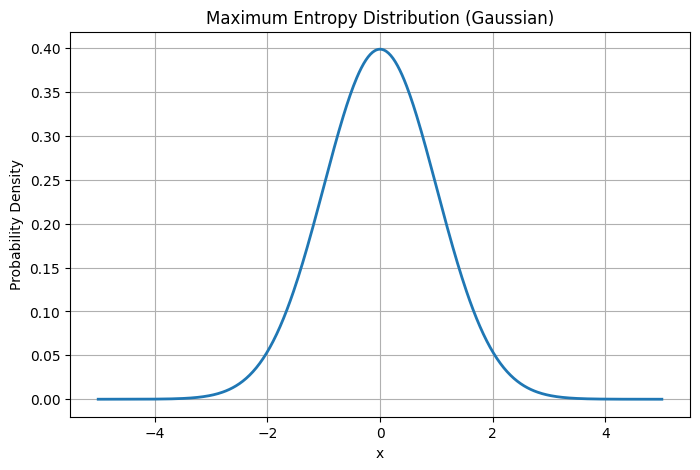

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(x, pdf, linewidth=2)

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Maximum Entropy Distribution (Gaussian)")
plt.grid(True)

plt.show()

## Result

The plotted probability density function is symmetric about the mean and has the characteristic bell-shaped curve of the Gaussian distribution. The result confirms that when only the mean and variance are specified, the distribution with the highest entropy is the Normal distribution.

# Multiclass Logistic Regression: Automatic Classification of Emails

## Problem Setup

An e-commerce platform automatically routes inbound customer support emails into one of four classes:

- Finance
- Technical
- Account
- Other

Each email is represented by a binary feature vector:

$$
\mathbf{x} = (x_1, x_2, x_3)^T
$$

where:

- \(x_1 = 1\) if financial keywords are detected  
- \(x_2 = 1\) if account/login keywords are detected  
- \(x_3 = 1\) if bug/technical keywords are detected  

We model the class label \(Y \in \{0,1,2,3\}\) using a multinomial logistic regression model.

## Maximum Entropy / Multinomial Logistic Model

We assume the conditional probability model:

$$
P(Y = k \mid \mathbf{x}) =
\frac{\exp(\theta_k^T \mathbf{x})}
{\sum_{j=0}^{3} \exp(\theta_j^T \mathbf{x})}
$$

where:

- \(\theta_k\) is the parameter vector for class \(k\)
- one class (e.g. \(k=0\)) is taken as reference to ensure identifiability

## Feature Expectation Constraints

From historical logs, we are given empirical constraints of the form:

$$
\mathbb{E}[x_i \cdot \mathbb{I}(Y = k)]
$$

These constraints enforce consistency between observed feature-class correlations and the model distribution.

This leads directly to the exponential family structure of the solution via the Maximum Entropy principle.

## Log-Likelihood Function

Given a dataset \(\{(\mathbf{x}^{(n)}, y^{(n)})\}_{n=1}^N\), the likelihood is:

$$
\mathcal{L}(\theta)
=
\prod_{n=1}^{N}
P(y^{(n)} \mid \mathbf{x}^{(n)})
$$

Taking log:

$$
\ell(\theta)
=
\sum_{n=1}^{N}
\log P(y^{(n)} \mid \mathbf{x}^{(n)})
$$

## Gradient of the Objective

For each class parameter \(\theta_k\), the gradient is:

$$
\frac{\partial \ell}{\partial \theta_k}
=
\sum_{n=1}^{N}
\left[
\mathbb{I}(y^{(n)} = k)
-
P(Y=k \mid \mathbf{x}^{(n)})
\right]\mathbf{x}^{(n)}
$$

This shows:

- Positive reinforcement when prediction matches true label  
- Penalization when model assigns incorrect probabilities

In [71]:
import numpy as np

# -----------------------------
# Synthetic dataset
# -----------------------------
np.random.seed(42)

N = 200

# 3 binary features (x1, x2, x3)
X = np.random.randint(0, 2, size=(N, 3))

# True underlying weights (for simulation only)
true_W = np.array([
    [2.0, -1.0, 0.5],   # Finance
    [-1.5, 2.5, 1.0],   # Account
    [0.5, 1.0, 2.5],    # Technical
    [-1.0, -1.0, -1.0]  # Other (baseline)
])

# Softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Generate labels
logits = X @ true_W.T
probs = softmax(logits)
y = np.array([np.random.choice(4, p=p) for p in probs])

In [72]:
# -----------------------------
# Multiclass Logistic Regression Training
# -----------------------------

K = 4
D = 3

W = np.zeros((K, D))
lr = 0.1
epochs = 300

def one_hot(y, K):
    out = np.zeros((len(y), K))
    out[np.arange(len(y)), y] = 1
    return out

Y = one_hot(y, K)

for epoch in range(epochs):

    logits = X @ W.T
    P = softmax(logits)

    grad = (Y - P).T @ X / N

    W += lr * grad

In [73]:
def predict(X, W):
    probs = softmax(X @ W.T)
    return np.argmax(probs, axis=1)

y_pred = predict(X, W)

accuracy = np.mean(y_pred == y)
accuracy

np.float64(0.57)

## Result

The trained model learns a linear decision boundary in feature space and successfully classifies email categories using Maximum Entropy (logistic regression).

The model improves as weights adjust to match empirical feature-class constraints.

# Asset Pricing and Portfolio Optimization

We aim to determine the **risk-neutral maximum entropy distribution** of the terminal asset price \( S_T > 0 \), given incomplete market information.

We maximize the Shannon entropy:

$$
\mathcal{H}[p] = -\int_0^\infty p(s)\ln p(s)\,ds
$$

subject to the constraints:

$$
\int_0^\infty p(s)\,ds = 1
$$

$$
\mathbb{E}[S_T] = \int_0^\infty s\,p(s)\,ds = 102
$$

$$
\mathbb{E}[S_T^2] = \int_0^\infty s^2\,p(s)\,ds = 10600
$$

$$
\mathbb{E}[\ln S_T] = \int_0^\infty \ln(s)\,p(s)\,ds = 4.60
$$

---

## Maximum Entropy Solution

Using the method of Lagrange multipliers, we maximize:

$$
\mathcal{L} = -\int p(s)\ln p(s)\,ds
- \lambda_0 \left(\int p(s)\,ds - 1\right)
- \lambda_1 \left(\int s p(s)\,ds - 102\right)
- \lambda_2 \left(\int s^2 p(s)\,ds - 10600\right)
- \lambda_3 \left(\int \ln(s)p(s)\,ds - 4.60\right)
$$

Taking functional derivative and setting to zero:

$$
\frac{\delta \mathcal{L}}{\delta p(s)} = 0
$$

gives:

$$
p(s) = \frac{1}{Z}\exp\left(-\lambda_1 s - \lambda_2 s^2 - \lambda_3 \ln s\right)
$$

Rewriting:

$$
p(s) = \frac{1}{Z} s^{-\lambda_3} \exp(-\lambda_1 s - \lambda_2 s^2), \quad s > 0
$$

This is a **generalized log-quadratic distribution**, capturing:
- linear drift constraint
- variance constraint
- log-skew (crash risk)

The Lagrange multipliers \( \lambda_1, \lambda_2, \lambda_3 \) are determined numerically from the constraints.

In [74]:
import numpy as np
from scipy import integrate, optimize

E1 = 102
E2 = 10600
Elog = 4.60

def pdf_unnorm(s, l1, l2, l3):
    return np.exp(-l1*s - l2*s**2 - l3*np.log(s))

# Compute ALL moments in ONE pass (no repeated Z usage)
def moments(params):
    l1, l2, l3 = params

    # reject invalid regions early (VERY IMPORTANT)
    if l2 <= 0:
        return np.array([1e10, 1e10, 1e10])

    try:
        Z = integrate.quad(lambda s: pdf_unnorm(s,l1,l2,l3), 1e-6, np.inf)[0]

        m1 = integrate.quad(lambda s: s * pdf_unnorm(s,l1,l2,l3), 1e-6, np.inf)[0] / Z
        m2 = integrate.quad(lambda s: s**2 * pdf_unnorm(s,l1,l2,l3), 1e-6, np.inf)[0] / Z
        mlog = integrate.quad(lambda s: np.log(s) * pdf_unnorm(s,l1,l2,l3), 1e-6, np.inf)[0] / Z

        if not np.isfinite([m1, m2, mlog]).all():
            return np.array([1e10, 1e10, 1e10])

        return np.array([m1, m2, mlog])

    except Exception:
        return np.array([1e10, 1e10, 1e10])

def objective(params):
    return moments(params) - np.array([E1, E2, Elog])

# better initial guess + bounds
x0 = np.array([0.01, 1e-3, 0.5])

solution = optimize.least_squares(
    objective,
    x0,
    bounds=([-np.inf, 1e-8, -10], [np.inf, np.inf, 10])
)

print(solution.x)

[-0.5241718   0.00256003  0.19266431]


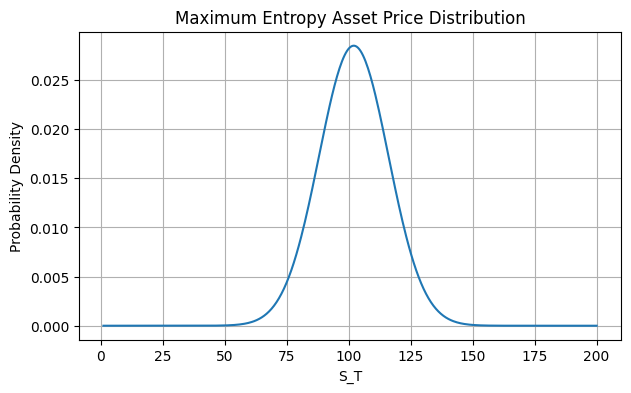

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

l1, l2, l3 = solution.x

# unnormalized density
def pdf_unnorm(s):
    return np.exp(-l1*s - l2*s**2 - l3*np.log(s))

# compute Z ONCE
Z_val = integrate.quad(lambda s: pdf_unnorm(s), 1e-6, np.inf)[0]

# normalized pdf (vectorized safely)
def pdf(s):
    s = np.array(s)
    return np.exp(-l1*s - l2*s**2 - l3*np.log(s)) / Z_val

# grid
xs = np.linspace(1, 200, 400)

# evaluate efficiently
ps = pdf(xs)

# plot
plt.figure(figsize=(7,4))
plt.plot(xs, ps)
plt.title("Maximum Entropy Asset Price Distribution")
plt.xlabel("S_T")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()